In [1]:
ENV["PYTHONPATH"] = "/home/gridsan/aligho/.local/lib/python3.8/site-packages/PyNormaliz-2.15-py3.8-linux-x86_64.egg";
D = 2;
using HDF5, PyPlot
using DelimitedFiles, PyPlot, LinearAlgebra, JLD2, PyCall, StaticArrays, Statistics
using Crystalline, Brillouin, MPBUtils, SymmetryBases
using Crystalline: TEST_αβγs, TEST_αβγ, dot, norm
using Crystalline: normscale, matching_littlegroups
using Crystalline: AbstractFourierLattice
topology_paper_dir = "../../TopologyPaper/"
include(topology_paper_dir * "get-freqs-symeigs.jl")
include(topology_paper_dir * "symeigs-from-io.jl");
include("../../Topology_ML/Phc_ML/fft.jl")
include("../get_uc_coefs.jl");
np = pyimport("numpy");

### We focus on the seventh topological category and find band structures that do not abide by the perturbation theory prediction at high contrast 

In [2]:
# Symmetry vectors corresponding to the eight classes
ns = [[0, 1, 0, 1, 0, 1, 1, 0, 1], [0, 1, 1, 0, 0, 1, 1, 0, 1], 
[0, 1, 0, 1, 1, 0, 1, 0, 1], [0, 1, 1, 0, 1, 0, 1, 0, 1], [1, 0, 0, 1, 0, 1, 1, 0, 1], 
[1, 0, 1, 0, 0, 1, 1, 0, 1], [1, 0, 0, 1, 1, 0, 1, 0, 1], [1, 0, 1, 0, 1, 0, 1, 0, 1]];
obstructed_idxs = [2, 3, 5, 8];
topological_idxs = [1, 4, 6, 7];

In [9]:
root_dir_smooth = "./inverse_design_smooth_symbols_random/"
root_dir_two_tone = "./inverse_design_two_tone_symbols_random/"

contrast_dispersion_dir = root_dir_two_tone * "changing_contrast/dispersion/output/sg2/tm/contrast6/"
contrast_dispersion_log_dir = root_dir_two_tone * "changing_contrast/dispersion/logs/"

contrast_dir = root_dir_two_tone * "changing_contrast/output/sg2/tm/contrast6/"
smooth_dir = root_dir_smooth * "output/sg2/tm/"

two_tone_dir = root_dir_two_tone * "output/sg2/tm/";

In [10]:
expect_to_be_good = []
for n in range(0, 7)
    filename = "two_tone_scores-class$(n).h5"
    f = h5open(root_dir_two_tone * filename, "r")
    which_good = findall(x-> x == n, np.argmax(f["two_tone_classifications"][], axis=0))
    push!(expect_to_be_good, which_good)
end

In [11]:
filename = "sg2-tm.jld2";
loaded_data = load(smooth_dir * filename);
N = 250
# Verify that all the smooth lattices are fine
symmetries_smooth = [[x[1].n for x in loaded_data["summariesv"][1+topological_class*N:(topological_class+1)*N]] for topological_class in range(0, 7)];

In [13]:
cat_idx_1_based = 7 # 1 based indexing of the topological category
cat_idx_0_based = cat_idx_1_based - 1 # 0 based indexing of the topological category
@assert all(n -> n == ns[cat_idx_1_based], symmetries_smooth[cat_idx_1_based])

In [129]:
filename = "sg2-tm.jld2";
loaded_data = load(smooth_dir * filename);
N = 250
symmetries_smooth = [[x[1].n for x in loaded_data["summariesv"][1+cat_idx_0_based*N:(cat_idx_0_based+1)*N]] for cat_idx_0_based in range(0, 7)];
filename = "sg2-tm.jld2";

loaded_data_two_tone = load(two_tone_dir * filename);
symmetries_two_tone = [[x[1].n for x in loaded_data_two_tone["summariesv"][1+cat_idx_0_based*N:(cat_idx_0_based+1)*N]] for cat_idx_0_based in range(0, 7)];

loaded_data_v = []

for contrast_idx in 1:6
    contrast_dir = "./inverse_design_two_tone_symbols_random/changing_contrast/output/sg2/tm/contrast$(contrast_idx)/"
    filename = "sg2-tm-contrast$(contrast_idx).jld2";
    loaded_data = load(contrast_dir * filename);
    push!(loaded_data_v, loaded_data)
end

In [130]:
contrast_idx = 6 # Highest contrast 
filtered_symmetries = [x[1].n for x in loaded_data_v[contrast_idx]["summariesv"][1+cat_idx_0_based*N:(cat_idx_0_based+1)*N]][expect_to_be_good[cat_idx_1_based]];

In [312]:
failure_idxs_filtered = findall(x->!(x == ns[cat_idx_1_based]), filtered_symmetries)
failure_idxs = expect_to_be_good[cat_idx_1_based][failure_idxs_filtered];

In [522]:
failure_idx = failure_idxs[21]
println("failure index: ", failure_idx)

contrast_idx = 1
println(loaded_data_v[contrast_idx]["summariesv"][1+cat_idx_0_based*N:(cat_idx_0_based+1)*N][failure_idx][1].n)

contrast_idx = 2
println(loaded_data_v[contrast_idx]["summariesv"][1+cat_idx_0_based*N:(cat_idx_0_based+1)*N][failure_idx][1].n)
println()

contrast_idx = 3
println(loaded_data_v[contrast_idx]["summariesv"][1+cat_idx_0_based*N:(cat_idx_0_based+1)*N][failure_idx][1].n)
println()

failure index: 122
[1, 0, 0, 1, 1, 0, 1, 0, 1]
[1, 0, 0, 1, 1, 0, 1, 0, 1]

[0, 1, 0, 1, 1, 0, 1, 0, 1]



### From the above, we see that for the 246th sample in the 7th (1-based indexing) topological category, there is a topological transition between contrast of 2 and contrast of 4. Therefore, we run a sweep for contrasts between 1 and 4 to see the gap closing at the Y point. Furhtermore, for the 122nd sample there is a transition between 4 and 6

In [95]:
transition_idx_1, transition_idx_2 = 1746, 1622;
G1 = pi*[2, -5/4]
G2 = 2*pi *[0, 5/4]; # Reciprocal lattice vectors

In [96]:
dispersionsv_topological_transition_dict = Dict{Integer, Vector{Matrix{Float64}}}()
y_empty_lattice_dispersion_dict = Dict{Integer, Vector{Float64}}()
kpts = Vector{Float64}()
contrasts_dict = Dict{Integer, Vector{Float64}}()
for transition_idx in [transition_idx_1, transition_idx_2]
    f = jldopen(contrast_dispersion_log_dir * "../../topological_transition/logs/" * "sg2-id$(transition_idx)-tm-log.jld2")
    logsv = f["logsv"];

    println("transition idx: ", transition_idx); flush(stdout);
    dispersionsv_topological_transition = Matrix{Float64}[];
    
    mean_epsilons = Float64[]
    harm_mean_epsilons = Float64[]

    contrasts = Float64[]
    
    for (id, logstr) in enumerate(logsv)
        dispersion_str = logs_to_dispersion(logstr, "tm");
        dispersion = readdlm(IOBuffer(dispersion_str), ',')[:, 6:end]
        dispersion = sort(dispersion, dims=2)
        push!(dispersionsv_topological_transition, dispersion)
        kpts = readdlm(IOBuffer(dispersion_str), ',')[:, 2:4];
        (id == 1) && global kpts = kpts
        splitted_log = split(logstr, " mean ")
        mean_epsilon =  parse(Float64, String(splitted_log[2])[1:end-7])
        harm_mean_epsilon = parse(Float64, split(String(splitted_log[3]), ",")[1])
        push!(mean_epsilons, mean_epsilon)
        push!(harm_mean_epsilons, harm_mean_epsilon)
        
        push!(contrasts, parse(Float64, split(String(split(logstr, "\nepsilon: ")[2]), ",")[1][3:end])) 
        
        ((id % 500) == 0) || continue
        println("ID: $id"); flush(stdout);
    end
    y_empty_lattice_dispersion = norm(G2/2)/(2*pi)./sqrt.(mean_epsilons);
    push!(contrasts_dict, transition_idx => contrasts)
    push!(y_empty_lattice_dispersion_dict, transition_idx => y_empty_lattice_dispersion)
    push!(dispersionsv_topological_transition_dict, transition_idx => dispersionsv_topological_transition)
end

transition idx: 1746
ID: 500
ID: 1000
ID: 1500
ID: 2000
transition idx: 1622
ID: 500
ID: 1000
ID: 1500
ID: 2000


In [97]:
A_point_idxs = findall(x-> isapprox(x, 0), [norm([0.5, 0.5, 0] .- collect(row)) for row in eachrow(kpts)])
Gamma_point_idxs = findall(x-> isapprox(x, 0), [norm([0, 0, 0] .- collect(row)) for row in eachrow(kpts)])
B_point_idxs = findall(x-> isapprox(x, 0), [norm([0.5, 0, 0] .- collect(row)) for row in eachrow(kpts)]);
Y_point_idxs = findall(x-> isapprox(x, 0), [norm([0, 0.5, 0] .- collect(row)) for row in eachrow(kpts)]);

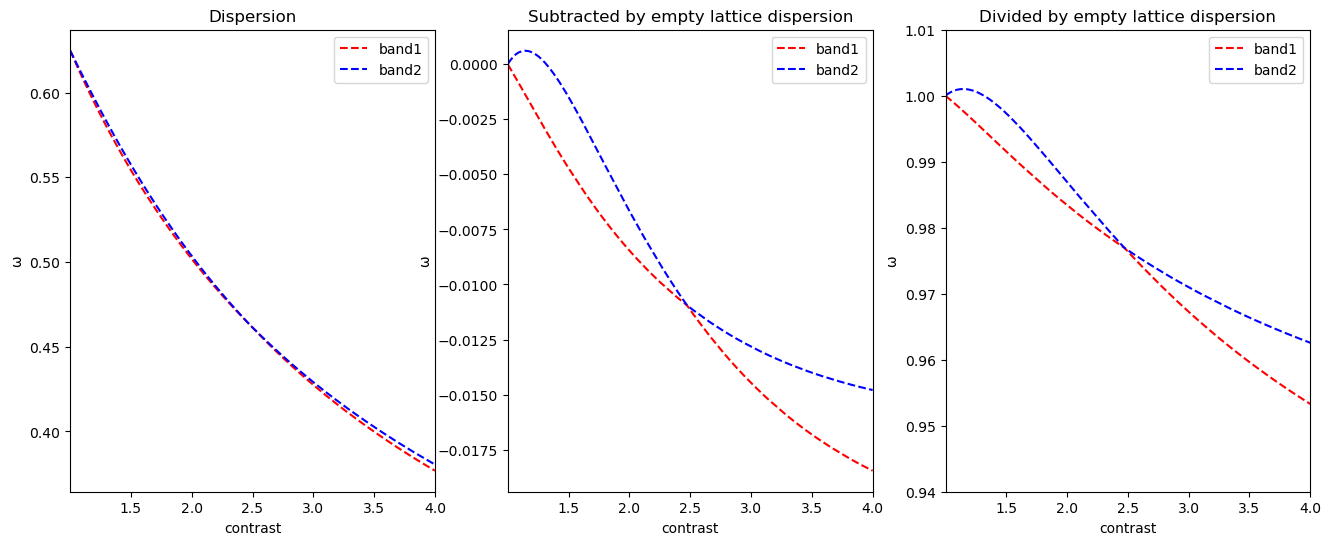

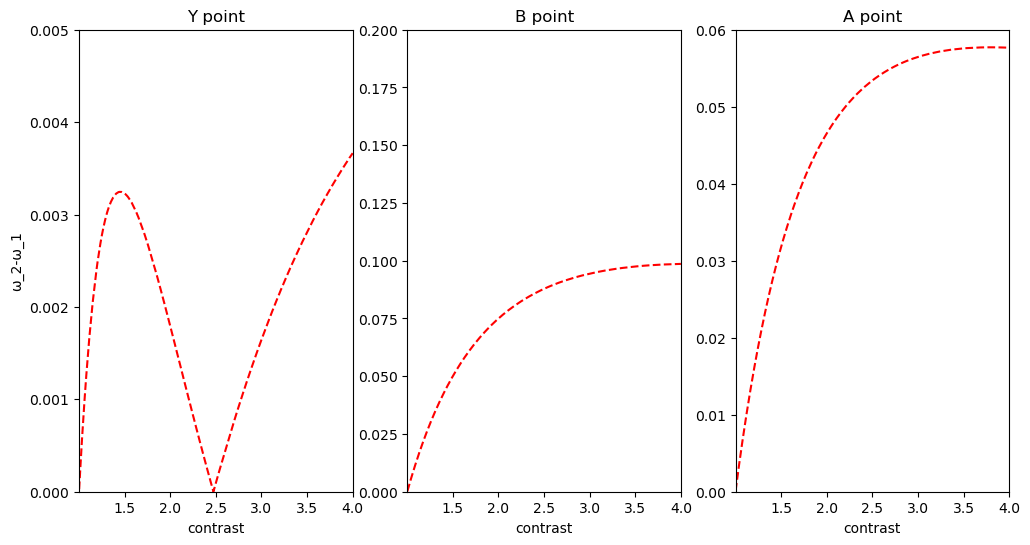

In [98]:
transition_idx = 1746
#transition_idx = 1622
dispersionsv_topological_transition = dispersionsv_topological_transition_dict[transition_idx]
y_point_diffs = [dispersionsv_topological_transition[idx][203, 2] - dispersionsv_topological_transition[idx][203, 1] for idx in 1:2000]
y_point_band_1 = [dispersionsv_topological_transition[idx][203, 1] for idx in 1:2000]
y_point_band_2 = [dispersionsv_topological_transition[idx][203, 2] for idx in 1:2000]

b_point_diffs = [dispersionsv_topological_transition[idx][1, 2] - dispersionsv_topological_transition[idx][1, 1] for idx in 1:2000]
b_point_band_1 = [dispersionsv_topological_transition[idx][1, 1] for idx in 1:2000]
b_point_band_2 = [dispersionsv_topological_transition[idx][1, 2] for idx in 1:2000]

a_point_diffs = [dispersionsv_topological_transition[idx][304, 2] - dispersionsv_topological_transition[idx][304, 1] for idx in 1:2000]
a_point_band_1 = [dispersionsv_topological_transition[idx][304, 1] for idx in 1:2000]
a_point_band_2 = [dispersionsv_topological_transition[idx][304, 2] for idx in 1:2000];

figure(figsize=(16, 6))
contrast_range = contrasts_dict[transition_idx]
y_empty_lattice_dispersion = y_empty_lattice_dispersion_dict[transition_idx]

subplot(1, 3, 1)
plot(contrast_range, y_point_band_1, color="red", linestyle="dashed", label="band1")
plot(contrast_range, y_point_band_2, color="blue", linestyle="dashed", label="band2")

xlabel("contrast")
ylabel("ω")
xlim(minimum(contrast_range), maximum(contrast_range))
title("Dispersion")

legend()

subplot(1, 3, 2)
plot(contrast_range, y_point_band_1-y_empty_lattice_dispersion, color="red", linestyle="dashed", label="band1")
plot(contrast_range, y_point_band_2-y_empty_lattice_dispersion, color="blue", linestyle="dashed", label="band2")
xlim(minimum(contrast_range), maximum(contrast_range))

xlabel("contrast")
ylabel("ω")
legend()
title("Subtracted by empty lattice dispersion")

subplot(1, 3, 3)
plot(contrast_range, y_point_band_1./y_empty_lattice_dispersion, color="red", linestyle="dashed", label="band1")
plot(contrast_range, y_point_band_2./y_empty_lattice_dispersion, color="blue", linestyle="dashed", label="band2")
xlabel("contrast")
title("Divided by empty lattice dispersion")
ylabel("ω")
legend()
ylim(0.94, 1.01)
xlim(minimum(contrast_range), maximum(contrast_range))
#savefig("./figures/topological_transition_fig1-idx_$(transition_idx).pdf")


figure(figsize=(12, 6))
subplot(1, 3, 1)
plot(contrast_range, y_point_diffs, color="red", linestyle="dashed")
#plot(contrast_range, a_point_diffs, color="red", linestyle="dashed")

xlabel("contrast")
ylabel("ω_2-ω_1")
ylim(0, 0.005)
xlim(minimum(contrast_range), maximum(contrast_range))
title("Y point")

subplot(1, 3, 2)
plot(contrast_range, b_point_diffs, color="red", linestyle="dashed")
xlim(minimum(contrast_range), maximum(contrast_range))
ylim(0, 0.2)
title("B point")
xlabel("contrast")

subplot(1, 3, 3)
plot(contrast_range, a_point_diffs, color="red", linestyle="dashed")
xlim(minimum(contrast_range), maximum(contrast_range))
ylim(0, 0.06);
title("A point");
xlabel("contrast");
#savefig("./figures/topological_transition_fig2-idx_$(transition_idx).pdf")
#xticks([])
#xticks([])

### Below, we verify that the above failure modes do not correspond to a change in the sign of the permittivity

In [69]:
inverse_design_dir = "./inverse_design_smooth_symbols_random/"
inverse_design_dir_1 = "./inverse_design_smooth_symbols/"
filename = "inverse_design_params-class$(cat_idx_0_based).h5"
filename_1 = "inverse_design_params-random-class$(cat_idx_0_based).h5"

f1 = h5open(inverse_design_dir * filename); # Important fourier coefficients
f2 = h5open(inverse_design_dir_1 * filename_1); 

epsilon_g_important_idx_1 = f1["inverse_design_params"][][:, transition_idx_1-cat_idx_0_based*250]
epsilon_g_important_idx_2 = f1["inverse_design_params"][][:, transition_idx_2-cat_idx_0_based*250];

epsilon_g_notimportant_idx_1 = f2["inverse_design_params_random"][][:, transition_idx_1-cat_idx_0_based*250]
epsilon_g_notimportant_idx_2 = f2["inverse_design_params_random"][][:, transition_idx_2-cat_idx_0_based*250];

close(f1)
close(f2)

In [73]:
epsilon_g_idx_1 = [epsilon_g_important_idx_1..., epsilon_g_notimportant_idx_1...]
epsilon_g_idx_2 = [epsilon_g_important_idx_2..., epsilon_g_notimportant_idx_2...];

In [74]:
Gs = [[-1, 0], [0, -1], [-1, -1], [-1, 1], [-2, 0], [0, -2], [-2, -1], [-2, 1], [-1, -2]] # Only include one reciprocal vector in each orbit
M = 64
xs = ys = np.linspace(-0.5, 0.5, M, endpoint=false)
xs = np.repeat(np.reshape(xs, (1, M)), M, axis=0);
ys = np.repeat(np.reshape(ys, (M, 1)), M, axis=1);
function smooth(X)
    epsilon_grid = np.zeros((M, M))
    for (CG, (Gx, Gy)) in zip(X, Gs)
        epsilon_grid += CG*np.cos(2*np.pi*xs*Gy + 2*np.pi*ys*Gx) # Note flip of Gx and Gy 
    end
    return epsilon_grid
end;

In [91]:
# Sanity check to make sure our scheme is valid (check that inverse fourier transforming gives us the expected epsilon_g values)
for epsilon_g in [epsilon_g_idx_1, epsilon_g_idx_2]
    epsilon_grid = smooth(epsilon_g);
    Cgs = np.zeros(9)
    for (m, G) in enumerate(Gs) 
        Gx, Gy = G
        G_grid = np.cos(2*np.pi*xs*Gy + 2*np.pi*ys*Gx)
        Cgs[m] = sum((G_grid .* epsilon_grid)*2/M/M) # Multiply by 2 since integral of cos^2 is 1/2
    end
    @assert isapprox(epsilon_g-Cgs, zeros(9), atol=1e-15)
end

In [131]:
Cgs_mat_dict = Dict{Integer, Matrix{Float64}}()
permittivity_real_space_dict = Dict{Integer, Matrix{Float64}}()
for (transition_idx, epsilon_g) in zip([transition_idx_1, transition_idx_2], [epsilon_g_idx_1, epsilon_g_idx_2])
    Cgs_mat = zeros(9, 2000)
    contrasts = contrasts_dict[transition_idx]
    epsilon_grid_smooth = smooth(epsilon_g);
    perc25, perc50, perc75 = np.percentile(epsilon_grid_smooth, [25, 50, 75]) # Find the threshold and quantiless
    for (contrast_idx, contrast) in enumerate(contrasts)
        epsilon_grid = np.where(epsilon_grid_smooth .< perc50, 1, contrast)
        if contrast_idx == 2000
            push!(permittivity_real_space_dict, transition_idx => epsilon_grid)
        end
        Cgs = np.zeros(9)
        for (m, G) in enumerate(Gs) 
            Gx, Gy = G
            G_grid = np.cos(2*np.pi*xs*Gy + 2*np.pi*ys*Gx)
            Cgs[m] = sum((G_grid .* epsilon_grid)*2/M/M) # Multiply by 2 since integral of cos^2 is 1/2
        end
        Cgs_mat[:, contrast_idx] = Cgs
    end
    push!(Cgs_mat_dict, transition_idx => Cgs_mat)
end

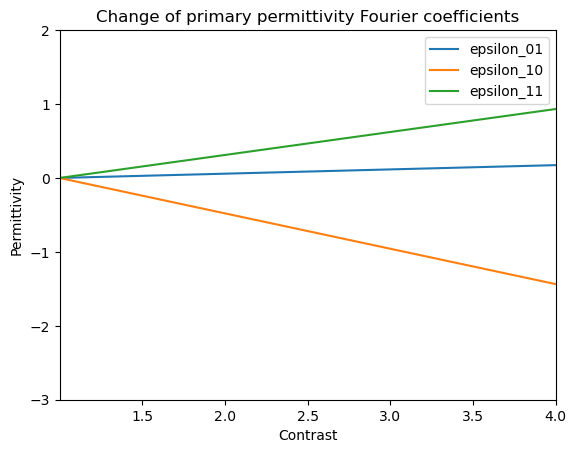

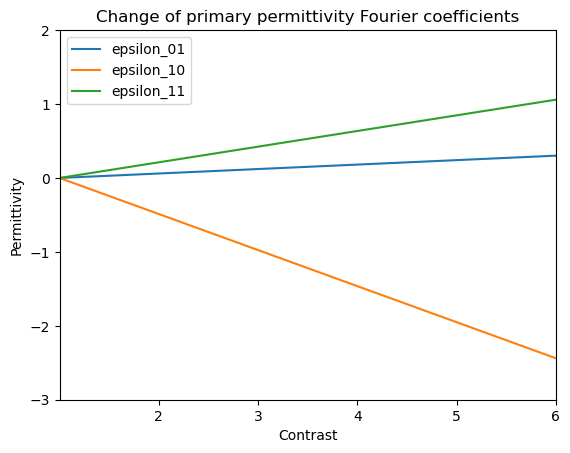

In [156]:
for transition_idx in [transition_idx_1, transition_idx_2]
    Cgs_mat = Cgs_mat_dict[transition_idx]
    contrasts = contrasts_dict[transition_idx]
    figure()
    plot(contrasts, Cgs_mat[1, :], label="epsilon_01")
    plot(contrasts, Cgs_mat[2, :], label="epsilon_10")
    plot(contrasts, Cgs_mat[3, :], label="epsilon_11")
    legend()
    xlim(minimum(contrasts), maximum(contrasts))
    ylim(-3, 2)
    title("Change of primary permittivity Fourier coefficients")
    xlabel("Contrast")
    ylabel("Permittivity")
    savefig("./figures/topological_transition_fourier_coefficients-idx_$(transition_idx).pdf")
end

In [157]:
permittivity_filename_1 = "dim2-sg2-$(transition_idx_1)-res64-tm-epsilon.h5"
f1 = h5open(two_tone_dir * permittivity_filename_1)
permittivity_idx1 = f1["data"][]
Rs_idx1 = f1["lattice vectors"][]
println("Lattice vectors from permittivity file: ", Rs_idx1)

permittivity_filename_2 = "dim2-sg2-$(transition_idx_2)-res64-tm-epsilon.h5"
f2 = h5open(two_tone_dir * permittivity_filename_2)
permittivity_idx2 = f2["data"][]
Rs_idx1 = f1["lattice vectors"][]
println("Lattice vectors from permittivity file: ", Rs_idx1)
close(f1)
close(f2);

Lattice vectors from permittivity file: [1.0 0.5 0.0; 0.0 0.8 0.0; 0.0 0.0 1.0]
Lattice vectors from permittivity file: [1.0 0.5 0.0; 0.0 0.8 0.0; 0.0 0.0 1.0]


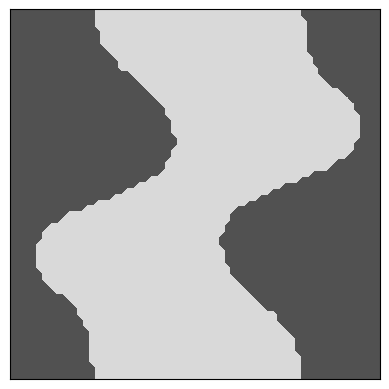

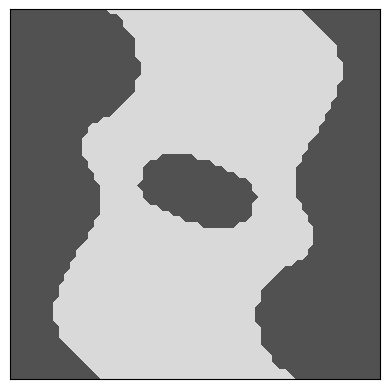

In [159]:
for transition_idx in [transition_idx_1, transition_idx_2]
    figure()
    contourf(xs, ys, permittivity_real_space_dict[transition_idx], levels=0, cmap="Greys")
    gca().set_aspect("equal")
    xticks([])
    yticks([])
    savefig("./figures/topological_transition_unit_cell-idx_$(transition_idx).pdf")
    xticks([])
    yticks([])
end

### Sanity check: check with saved hdf5 files

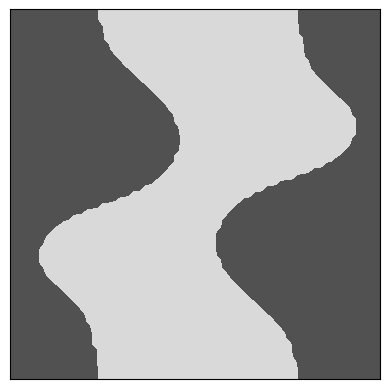

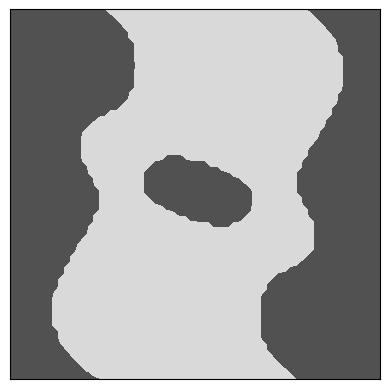

In [163]:
figure()
contourf(xs, ys, permittivity_idx1, levels=0, cmap="Greys")
gca().set_aspect("equal")
xticks([])
yticks([]);

figure()
contourf(xs, ys, permittivity_idx2, levels=0, cmap="Greys")
gca().set_aspect("equal")
xticks([])
yticks([]);